In [1]:
# Runtime evidence: this cell checks the environment actually used by the kernel.
import sys as _shape_sys, json as _shape_json, importlib.util as _shape_util
print("SHAPE_RUNTIME_PROVENANCE=" + _shape_json.dumps({
    "python_executable": _shape_sys.executable,
    "python_version": _shape_sys.version.split()[0],
    "shape_lab_origin": _shape_util.find_spec("shape_lab").origin
}))
del _shape_sys, _shape_json, _shape_util


SHAPE_RUNTIME_PROVENANCE={"python_executable": "/opt/pyvenv/bin/python", "python_version": "3.13.5", "shape_lab_origin": "/tmp/shape-course-q90rdcpz/course/src/shape_lab/__init__.py"}


# Stage 25 — Constraints, projections, retractions and rank failure

Measured Iris vectors subjected to an explicitly chosen unit-sphere normalization; exact and nonlinear constraint counterexamples.

This is an executed reference, not a learner assessment. Read the lesson and predict the results before running. All code is inspectable in `src/shape_lab/physics`. No model or dataset downloads occur.

In [2]:
from IPython import get_ipython
if get_ipython() is not None:
    get_ipython().run_line_magic('matplotlib','inline')
STAGE=25
from pathlib import Path
import sys, json, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
ROOT=Path.cwd()
while not (ROOT/'pyproject.toml').exists() and ROOT.parent!=ROOT:ROOT=ROOT.parent
if not (ROOT/'pyproject.toml').exists():raise RuntimeError('Open this notebook within the extracted project.')
sys.path.insert(0,str(ROOT/'src'))
from shape_lab.physics import classical as c, constraints as con, gradients as grad, operators as op
hahn=pd.read_csv(ROOT/'data/physics/hahn1_excerpt.csv')
hahn_manifest=json.loads((ROOT/'data/physics/manifest.json').read_text())
OUT=ROOT/'physics/reports'/f'{STAGE:02d}'
OUT.mkdir(parents=True,exist_ok=True)
def save_report(result):
    result={'stage':STAGE,'role':'executed teaching experiment; not learner assessment',**result}
    result['source_review_date']='2026-09-20'
    (OUT/'results.json').write_text(json.dumps(result,indent=2,allow_nan=False)+'\n')
    print(json.dumps(result,indent=2))
def finish_figure(name):
    plt.tight_layout();plt.savefig(OUT/f'{name}.png',dpi=140,bbox_inches='tight');plt.show();plt.close()
print('Course:', ROOT.name, '| stage:', STAGE)


Course: course | stage: 25


## Linearized correction versus exact constraint satisfaction
Predict the first result and residual before allowing any iterations.

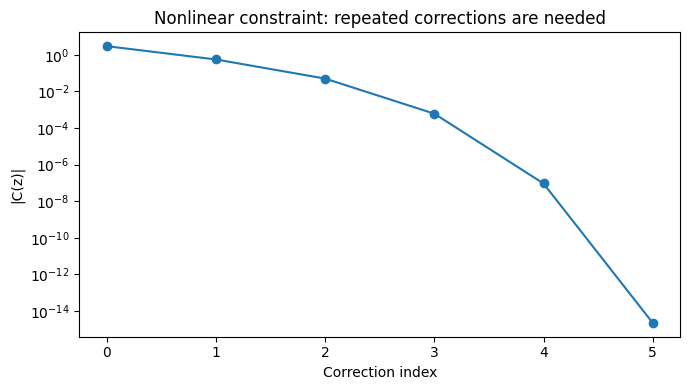

Expected singularity: Sphere constraint has a rank-zero Jacobian at the origin.


In [3]:
first=con.constraint_correction([2.,0.],[3.],[[4.,0.]])
assert np.allclose(first,[1.25,0.]);assert abs(first@first-1-.5625)<1e-12
projected,history=con.project_sphere([2.,0.])
plt.figure(figsize=(7,4));plt.semilogy(range(len(history)),np.maximum(history,1e-16),'o-');plt.xlabel('Correction index');plt.ylabel('|C(z)|');plt.title('Nonlinear constraint: repeated corrections are needed');finish_figure('correction')
try:con.project_sphere([0.,0.])
except ValueError as error:print('Expected singularity:',error)
else:raise AssertionError('Rank-zero input accepted.')

## A chosen unit-sphere representation of observations
Normalize Iris features and report the information removed. This is a preprocessing decision, not a physical law.

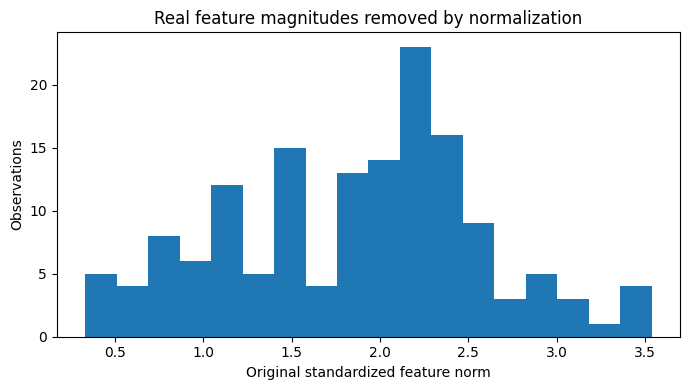

{
  "stage": 25,
  "role": "executed teaching experiment; not learner assessment",
  "data_kind": "constructed constraint operation on observed Iris features",
  "one_step_result": [
    1.25,
    0.0
  ],
  "one_step_constraint_residual": 0.5625,
  "iterative_residuals": [
    3.0,
    0.5625,
    0.05062499999999992,
    0.0006098490481853958,
    9.292229696811205e-08,
    2.220446049250313e-15
  ],
  "observed_rows": 150,
  "normalized_max_constraint_error": 4.440892098500626e-16,
  "unsupported": "Not a geodesic solver, symplectic constrained integrator, or biological conservation test.",
  "source_review_date": "2026-09-20"
}


In [4]:
iris=pd.read_csv(ROOT/'data/raw/iris.csv');X=iris.iloc[:,1:5].to_numpy(dtype=float)
X=(X-X.mean(axis=0))/X.std(axis=0);norm=np.linalg.norm(X,axis=1)
assert np.all(norm>0)
U=X/norm[:,None];residual=np.abs(np.sum(U*U,axis=1)-1)
plt.figure(figsize=(7,4));plt.hist(norm,bins=18);plt.xlabel('Original standardized feature norm');plt.ylabel('Observations');plt.title('Real feature magnitudes removed by normalization');finish_figure('removed_norms')
save_report({'data_kind':'constructed constraint operation on observed Iris features','one_step_result':first.tolist(),'one_step_constraint_residual':float(first@first-1),'iterative_residuals':history,'observed_rows':len(X),'normalized_max_constraint_error':float(residual.max()),'unsupported':'Not a geodesic solver, symplectic constrained integrator, or biological conservation test.'})

## Independent explanation

Write the data origin, one supported conclusion and one unsupported conclusion. Change one parameter while preserving the comparison horizon or unit. Save your answer separately; successful reference execution is not proof that you understand the result.